## 1. Install Libraries

In [ ]:
!pip install torch torchvision --quiet
!pip install scikit-learn matplotlib seaborn --quiet
!pip install onnx onnxruntime --quiet

import torch
import torchvision
import sklearn
import matplotlib
import onnx

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU -- switch to GPU in Runtime menu!")

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
GPU available: True
Device: Tesla T4


## 2. Mount Google Drive and Locate Dataset

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

#Dataset Directory
DATASET_DIR = '/content/drive/MyDrive/Forest Fire_Dataset'

# Verify the dataset folder exists and show structure
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_DIR}\n"
        "Update DATASET_DIR above to match your Drive folder path."
    )

print("Dataset found. Checking structure...\n")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(DATASET_DIR, split)
    if os.path.exists(split_path):
        classes = sorted(os.listdir(split_path))
        print(f"{split}/")
        for cls in classes:
            count = len(os.listdir(os.path.join(split_path, cls)))
            print(f"  {cls}/  ->  {count} images")
    else:
        print(f"WARN: {split}/ not found inside {DATASET_DIR}")

Mounted at /content/drive
Dataset found. Checking structure...

train/
  fire/  ->  800 images
  nofire/  ->  800 images
  smoke/  ->  800 images
  smokefire/  ->  800 images
val/
  fire/  ->  200 images
  nofire/  ->  200 images
  smoke/  ->  200 images
  smokefire/  ->  200 images
test/
  fire/  ->  200 images
  nofire/  ->  200 images
  smoke/  ->  200 images
  smokefire/  ->  200 images


## 3. DataLoaders

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# -- Paths (uses DATASET_DIR set in Cell 2)
TRAIN_DIR = os.path.join(DATASET_DIR, 'train')
VAL_DIR   = os.path.join(DATASET_DIR, 'val')
TEST_DIR  = os.path.join(DATASET_DIR, 'test')

# -- Config
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2
NUM_CLASSES = 4

# -- Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# -- Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

# -- DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# -- Verify
CLASS_NAMES = train_dataset.classes
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Classes       :", CLASS_NAMES)
print("Class indices :", train_dataset.class_to_idx)
print()
print(f"Train batches : {len(train_loader)}  ({len(train_dataset)} images)")
print(f"Val batches   : {len(val_loader)}  ({len(val_dataset)} images)")
print(f"Test batches  : {len(test_loader)}  ({len(test_dataset)} images)")
print(f"Training on   : {DEVICE}")

Classes       : ['fire', 'nofire', 'smoke', 'smokefire']
Class indices : {'fire': 0, 'nofire': 1, 'smoke': 2, 'smokefire': 3}

Train batches : 100  (3200 images)
Val batches   : 25  (800 images)
Test batches  : 25  (800 images)
Training on   : cuda


## 4. Model 1: Baseline CNN

In [ ]:
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from sklearn.metrics import classification_report, confusion_matrix

class BaselineCNN(nn.Module):
    """
    Simple CNN built from scratch.
    3 convolutional blocks followed by a fully connected classifier.
    This is the performance floor -- no tuning, no pretrained weights.
    """
    def __init__(self, num_classes=4):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 224 -> 112
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 112 -> 56
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 56 -> 28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Shared Training Helpers (used by all 3 models)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def run_training(model, model_name, train_loader, val_loader, test_loader,
                 criterion, optimizer, device, epochs=20, patience=5):
    """
    Full training loop with early stopping.
    Saves best weights based on val accuracy.
    Returns history dict.
    """
    best_val_acc, best_weights, patience_count = 0.0, None, 0
    train_losses, val_losses, train_accs, val_accs, test_accs_log = [], [], [], [], []

    print(f"\nTraining {model_name}...")
    print(f"{'Epoch':<8} {'Train Loss':<14} {'Train Acc':<14} {'Val Loss':<14} {'Val Acc':<12} {'Test Acc'}")
    print("-" * 75)

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        train_accs.append(tr_acc)
        val_accs.append(vl_acc)

        if epoch % 5 == 0 or epoch == 1:
            _, ts_acc = evaluate(model, test_loader, criterion, device)
            test_accs_log.append((epoch, ts_acc))
            test_acc_str = f"{ts_acc:.4f}"
        else:
            test_acc_str = "-"

        print(f"{epoch:<8} {tr_loss:<14.4f} {tr_acc:<14.4f} {vl_loss:<14.4f} {vl_acc:<12.4f} {test_acc_str}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\nEarly stopping at epoch {epoch} -- no val improvement for {patience} epochs.")
                break

    elapsed = time.time() - start_time
    print(f"\nTraining complete in {elapsed/60:.1f} minutes")
    print(f"Best Val Accuracy: {best_val_acc:.4f}")

    model.load_state_dict(best_weights)
    _, final_test_acc = evaluate(model, test_loader, criterion, device)
    labels_true, labels_pred = get_predictions(model, test_loader, device)

    print(f"Final Test Accuracy (best weights): {final_test_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(labels_true, labels_pred, target_names=CLASS_NAMES))

    return model, {
        'name':          model_name,
        'train_losses':  train_losses,
        'val_losses':    val_losses,
        'train_accs':    train_accs,
        'val_accs':      val_accs,
        'test_accs_log': test_accs_log,
        'best_val_acc':  best_val_acc,
        'test_acc':      final_test_acc,
        'labels_true':   labels_true.tolist(),
        'labels_pred':   labels_pred.tolist(),
        'report':        classification_report(labels_true, labels_pred,
                                               target_names=CLASS_NAMES, output_dict=True),
    }


def run_training_with_scheduler(model, model_name, train_loader, val_loader, test_loader,
                                 criterion, optimizer, scheduler, device, epochs=20, patience=5):
    """
    Same as run_training but steps a LR scheduler each epoch.
    """
    best_val_acc, best_weights, patience_count = 0.0, None, 0
    train_losses, val_losses, train_accs, val_accs, test_accs_log = [], [], [], [], []

    print(f"\nTraining {model_name}...")
    print(f"{'Epoch':<8} {'Train Loss':<14} {'Train Acc':<14} {'Val Loss':<14} {'Val Acc':<12} {'Test Acc':<12} {'LR'}")
    print("-" * 90)

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        train_accs.append(tr_acc)
        val_accs.append(vl_acc)

        scheduler.step(vl_acc)
        current_lr = optimizer.param_groups[0]['lr']

        if epoch % 5 == 0 or epoch == 1:
            _, ts_acc = evaluate(model, test_loader, criterion, device)
            test_accs_log.append((epoch, ts_acc))
            test_acc_str = f"{ts_acc:.4f}"
        else:
            test_acc_str = "-"

        print(f"{epoch:<8} {tr_loss:<14.4f} {tr_acc:<14.4f} {vl_loss:<14.4f} {vl_acc:<12.4f} {test_acc_str:<12} {current_lr:.6f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\nEarly stopping at epoch {epoch} -- no val improvement for {patience} epochs.")
                break

    elapsed = time.time() - start_time
    print(f"\nTraining complete in {elapsed/60:.1f} minutes")
    print(f"Best Val Accuracy: {best_val_acc:.4f}")

    model.load_state_dict(best_weights)
    _, final_test_acc = evaluate(model, test_loader, criterion, device)
    labels_true, labels_pred = get_predictions(model, test_loader, device)

    print(f"Final Test Accuracy (best weights): {final_test_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(labels_true, labels_pred, target_names=CLASS_NAMES))

    return model, {
        'name':          model_name,
        'train_losses':  train_losses,
        'val_losses':    val_losses,
        'train_accs':    train_accs,
        'val_accs':      val_accs,
        'test_accs_log': test_accs_log,
        'best_val_acc':  best_val_acc,
        'test_acc':      final_test_acc,
        'labels_true':   labels_true.tolist(),
        'labels_pred':   labels_pred.tolist(),
        'report':        classification_report(labels_true, labels_pred,
                                               target_names=CLASS_NAMES, output_dict=True),
    }

# Train Model 1
EPOCHS   = 13
LR       = 0.001
PATIENCE = 5

model1    = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=LR)

model1, history1 = run_training(
    model1, 'Model1_BaselineCNN',
    train_loader, val_loader, test_loader,
    criterion, optimizer, DEVICE,
    epochs=EPOCHS, patience=PATIENCE,
)


Training Model1_BaselineCNN...
Epoch    Train Loss     Train Acc      Val Loss       Val Acc      Test Acc
---------------------------------------------------------------------------
1        1.0362         0.6169         0.7336         0.7150       0.5475
2        0.6754         0.7394         0.5686         0.7788       -
3        0.6074         0.7703         0.5076         0.8087       -
4        0.5688         0.7759         0.4878         0.8113       -
5        0.5340         0.7831         0.5066         0.8050       0.7125
6        0.5210         0.7953         0.5234         0.7900       -
7        0.4951         0.8091         0.4894         0.8137       -
8        0.4800         0.8206         0.4332         0.8300       -
9        0.4704         0.8181         0.3935         0.8462       -
10       0.4348         0.8281         0.4265         0.8363       0.6775
11       0.4404         0.8284         0.4032         0.8475       -
12       0.4158         0.8356         0.4

## 5. Saving Model 1 and  Plotting Graphs

Weights saved: /content/checkpoints/model1_baseline_cnn.pth
History saved: /content/checkpoints/model1_history.json


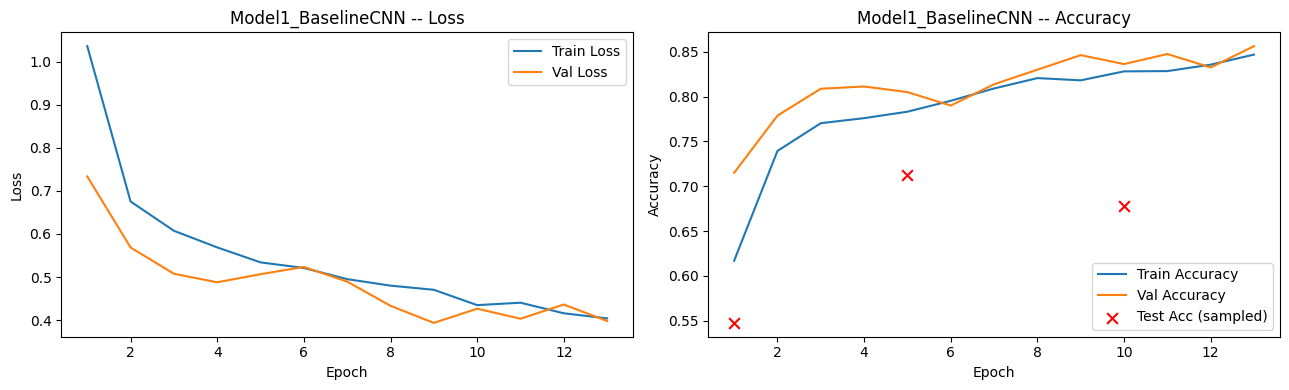

Saved: /content/checkpoints/Model1_BaselineCNN_curves.png


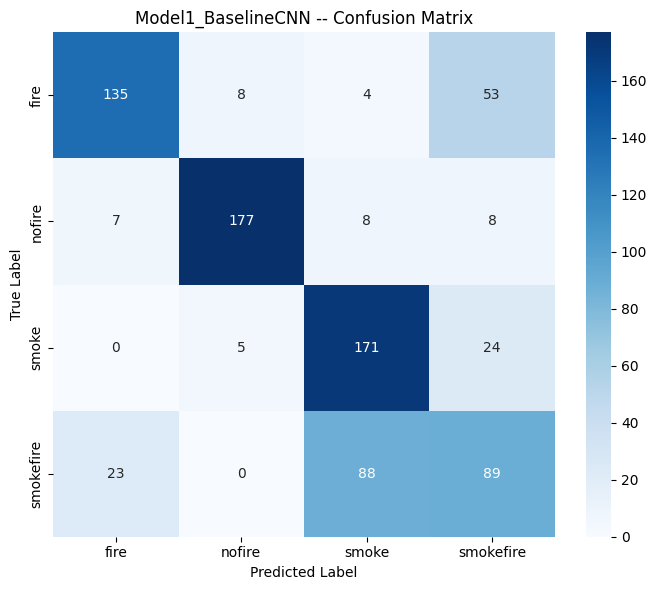

Saved: /content/checkpoints/Model1_BaselineCNN_confusion.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from sklearn.metrics import confusion_matrix

SAVE_DIR = '/content/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# Plot helpers (shared across all models)

def plot_training_curves(history, save_dir):
    name   = history['name']
    epochs = range(1, len(history['train_accs']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(epochs, history['train_losses'], label='Train Loss')
    ax1.plot(epochs, history['val_losses'],   label='Val Loss')
    ax1.set_title(f'{name} -- Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, history['train_accs'], label='Train Accuracy')
    ax2.plot(epochs, history['val_accs'],   label='Val Accuracy')
    if history.get('test_accs_log'):
        test_epochs = [e for e, _ in history['test_accs_log']]
        test_vals   = [a for _, a in history['test_accs_log']]
        ax2.scatter(test_epochs, test_vals, color='red', zorder=5,
                    label='Test Acc (sampled)', marker='x', s=60)
    ax2.set_title(f'{name} -- Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    path = f'{save_dir}/{name}_curves.png'
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")


def plot_confusion_matrix(history, class_names, save_dir):
    name = history['name']
    cm   = confusion_matrix(history['labels_true'], history['labels_pred'])

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{name} -- Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    path = f'{save_dir}/{name}_confusion.png'
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")

# Save Model 1

weights_path = f'{SAVE_DIR}/model1_baseline_cnn.pth'
torch.save(model1.state_dict(), weights_path)
print(f"Weights saved: {weights_path}")

with open(f'{SAVE_DIR}/model1_history.json', 'w') as f:
    json.dump(history1, f)
print(f"History saved: {SAVE_DIR}/model1_history.json")

# Plots
plot_training_curves(history1, SAVE_DIR)
plot_confusion_matrix(history1, CLASS_NAMES, SAVE_DIR)

In [ ]:
# Downloading the saved weights and history to local PC (Colab specific)
from google.colab import files
files.download(weights_path)
files.download(f'{SAVE_DIR}/model1_history.json')
print("Downloads Completed")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started................


## 6. Model 2: Tuned CNN

In [ ]:
class TunedCNN(nn.Module):
    """
    Improved CNN with:
    - BatchNorm after each conv layer (training stability)
    - Dropout for regularisation
    - 3 blocks (same depth as baseline -- dataset size does not justify more)
    - Larger FC layer: 512 units
    """
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super(TunedCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 224 -> 112
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 112 -> 56
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 56 -> 28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Class weights -- equal attention to all 4 classes

class_counts  = torch.tensor([800.0, 800.0, 800.0, 800.0])
class_weights = (1.0 / class_counts)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(DEVICE)
print("Class weights:", class_weights)

# Train Model 2

EPOCHS   = 30
LR       = 0.001
PATIENCE = 7

model2    = TunedCNN(num_classes=NUM_CLASSES, dropout_rate=0.3).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model2.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

model2, history2 = run_training_with_scheduler(
    model2, 'Model2_TunedCNN',
    train_loader, val_loader, test_loader,
    criterion, optimizer, scheduler, DEVICE,
    epochs=EPOCHS, patience=PATIENCE,
)

Class weights: tensor([1., 1., 1., 1.], device='cuda:0')

Training Model2_TunedCNN...
Epoch    Train Loss     Train Acc      Val Loss       Val Acc      Test Acc     LR
------------------------------------------------------------------------------------------
1        4.0349         0.6153         0.5862         0.7825       0.6637       0.001000
2        0.7919         0.6837         0.5719         0.7700       -            0.001000
3        0.7255         0.7166         0.5290         0.7937       -            0.001000
4        0.7259         0.7241         0.5752         0.7675       -            0.001000
5        0.6952         0.7391         0.4730         0.8387       0.6700       0.001000
6        0.6761         0.7472         0.5736         0.7863       -            0.001000
7        0.6850         0.7384         0.5224         0.7837       -            0.001000
8        0.6406         0.7591         0.5527         0.7712       -            0.001000
9        0.6645         0.74

## 7. Saving Model 2 and Plotting Grpahs

Weights saved: /content/checkpoints/model2_tuned_cnn.pth
History saved: /content/checkpoints/model2_history.json


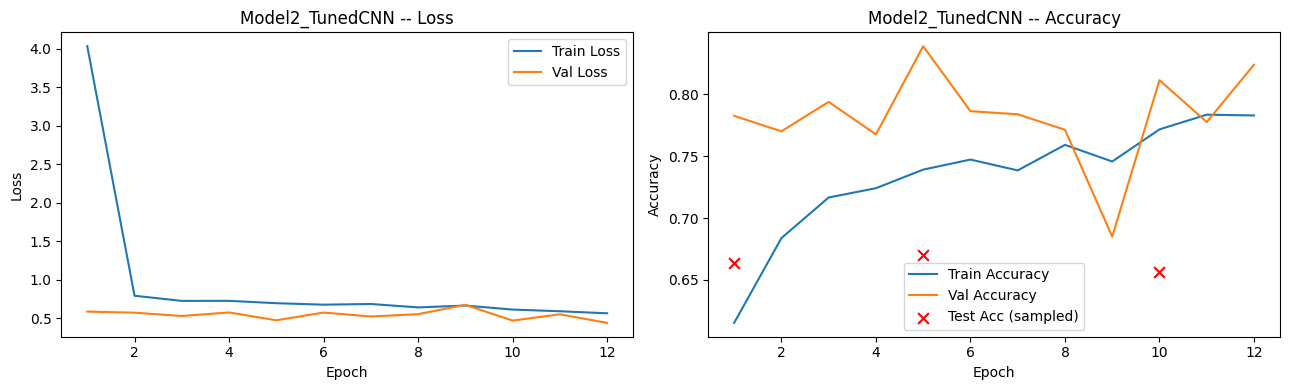

Saved: /content/checkpoints/Model2_TunedCNN_curves.png


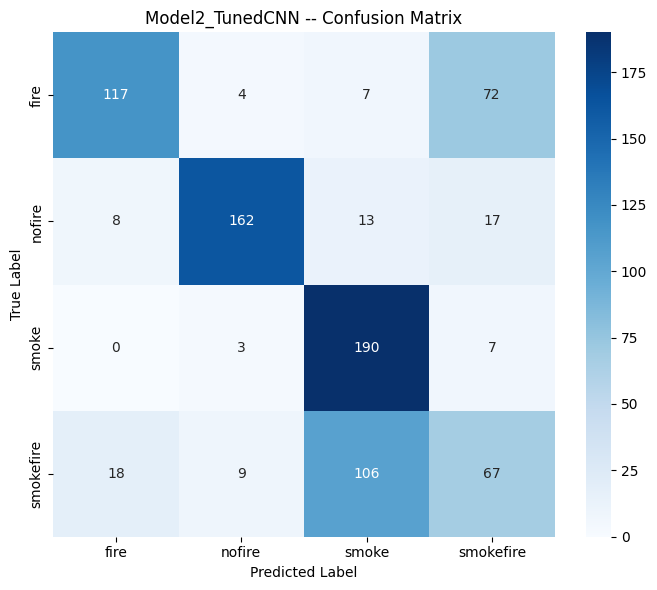

Saved: /content/checkpoints/Model2_TunedCNN_confusion.png


In [11]:
weights_path = f'{SAVE_DIR}/model2_tuned_cnn.pth'
torch.save(model2.state_dict(), weights_path)
print(f"Weights saved: {weights_path}")

with open(f'{SAVE_DIR}/model2_history.json', 'w') as f:
    json.dump(history2, f)
print(f"History saved: {SAVE_DIR}/model2_history.json")

plot_training_curves(history2, SAVE_DIR)
plot_confusion_matrix(history2, CLASS_NAMES, SAVE_DIR)

In [ ]:
#Downloading the saved weights and history to local PC (Colab specific)
from google.colab import files
files.download(weights_path)
files.download(f'{SAVE_DIR}/model1_history.json')
print("Downloads Completed")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started..............


## 8. Model 3: Fine-tuned MobileNetV3

In [ ]:
# Cell 6 -- Model 3: Fine-tuned MobileNetV3 (transfer learning)

from torchvision import models

model3 = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# Freeze all backbone layers
for param in model3.parameters():
    param.requires_grad = False

# Replace the classifier head with our own (4 output classes)
in_features = model3.classifier[3].in_features
model3.classifier[3] = nn.Linear(in_features, NUM_CLASSES)

model3 = model3.to(DEVICE)

# Count trainable parameters
trainable = sum(p.numel() for p in model3.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model3.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")
print("Phase 1: Training classifier head only (backbone frozen)")

# Phase 1 -- Train head only (backbone frozen), 10 epochs

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model3.parameters()), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

model3, history3_phase1 = run_training_with_scheduler(
    model3, 'Model3_MobileNetV3_Phase1',
    train_loader, val_loader, test_loader,
    criterion, optimizer, scheduler, DEVICE,
    epochs=10, patience=5,
)

# Unfreeze top layers and fine-tune with lower LR
print("\nPhase 2: Unfreezing top backbone layers for fine-tuning...")

# Unfreeze the last 2 feature blocks + classifier
for name, param in model3.named_parameters():
    if 'features.11' in name or 'features.12' in name or 'classifier' in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in model3.parameters() if p.requires_grad)
print(f"Trainable parameters after unfreeze: {trainable:,}")

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model3.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

model3, history3 = run_training_with_scheduler(
    model3, 'Model3_MobileNetV3',
    train_loader, val_loader, test_loader,
    criterion, optimizer, scheduler, DEVICE,
    epochs=20, patience=7,
)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 139MB/s]

Trainable parameters: 4,100 / 1,521,956
Phase 1: Training classifier head only (backbone frozen)

Training Model3_MobileNetV3_Phase1...
Epoch    Train Loss     Train Acc      Val Loss       Val Acc      Test Acc     LR
------------------------------------------------------------------------------------------


1        0.6827         0.7762         0.4191         0.8488       0.6725       0.001000
2        0.4248         0.8541         0.3415         0.8788       -            0.001000
3        0.3742         0.8716         0.3148         0.8825       -            0.001000
4        0.3451         0.8731         0.2926         0.8950       -            0.001000
5        0.3354         0.8762         0.2847         0.9000       0.6663       0.001000
6        0.3133         0.8819         0.2775         0.9025       -            0.001000
7        0.3105         0.8803         0.2611         0.9087       -            0.001000
8        0.3009         0.8894         0.2617         0.9100       -            0.001000
9        0.2982         0.8784         0.2580         0.9125       -            0.001000
10       0.2857         0.8912         0.2464         0.9075       0.7037       0.001000

Training complete in 5.8 minutes
Best Val Accuracy: 0.9125
Final Test Accuracy (best weights): 0.6875

Classi

## 9. Saving Model 3 and Plotting

Weights saved: /content/checkpoints/model3_mobilenetv3.pth
History saved: /content/checkpoints/model3_history.json


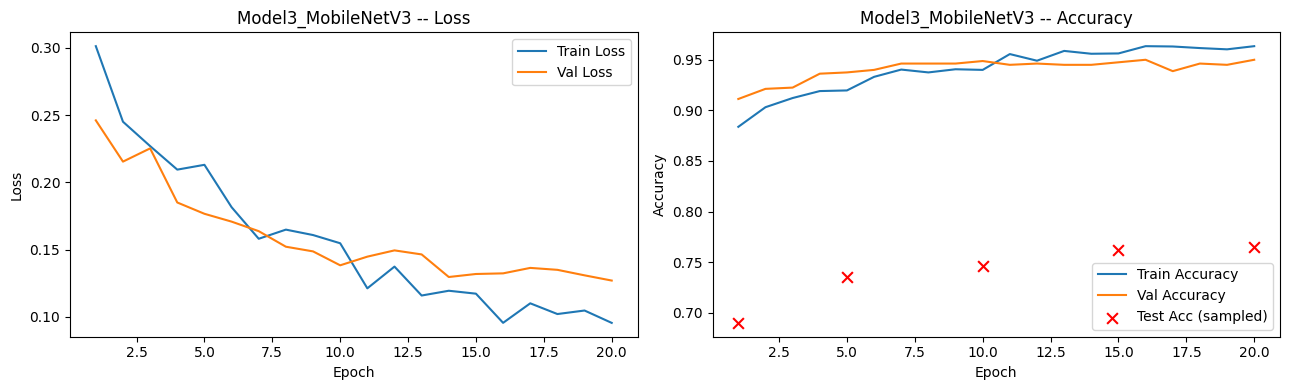

Saved: /content/checkpoints/Model3_MobileNetV3_curves.png


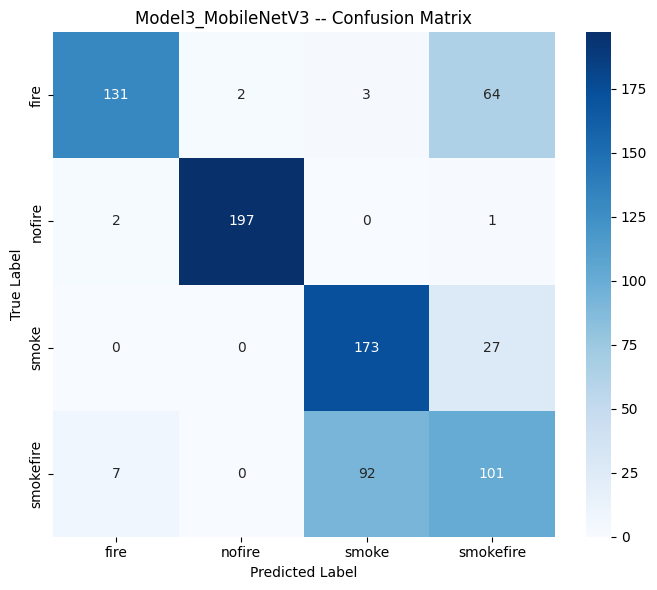

Saved: /content/checkpoints/Model3_MobileNetV3_confusion.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started...........


In [ ]:
weights_path = f'{SAVE_DIR}/model3_mobilenetv3.pth'
torch.save(model3.state_dict(), weights_path)
print(f"Weights saved: {weights_path}")

with open(f'{SAVE_DIR}/model3_history.json', 'w') as f:
    json.dump(history3, f)
print(f"History saved: {SAVE_DIR}/model3_history.json")

plot_training_curves(history3, SAVE_DIR)
plot_confusion_matrix(history3, CLASS_NAMES, SAVE_DIR)


#Downloading the saved weights and history to local PC (Colab specific)
from google.colab import files
files.download(weights_path)
files.download(f'{SAVE_DIR}/model3_history.json')
print("Downloads Completed")

## 10. Compare All 3 Models

Model                          Best Val Acc   Test Acc   F1 (macro)
---------------------------------------------------------------------------
Model1_BaselineCNN                   0.8562     0.7150       0.7124
Model2_TunedCNN                      0.8387     0.6700       0.6612
Model3_MobileNetV3                   0.9500     0.7525       0.7528

Per-class F1-score comparison:
Class           Model1_BaselineCNN     Model2_TunedCNN  Model3_MobileNetV3
---------------------------------------------------------------------------
fire                        0.7397              0.6822              0.7706
nofire                      0.9077              0.8571              0.9875
smoke                       0.7261              0.7364              0.7393
smokefire                   0.4759              0.3691              0.5140


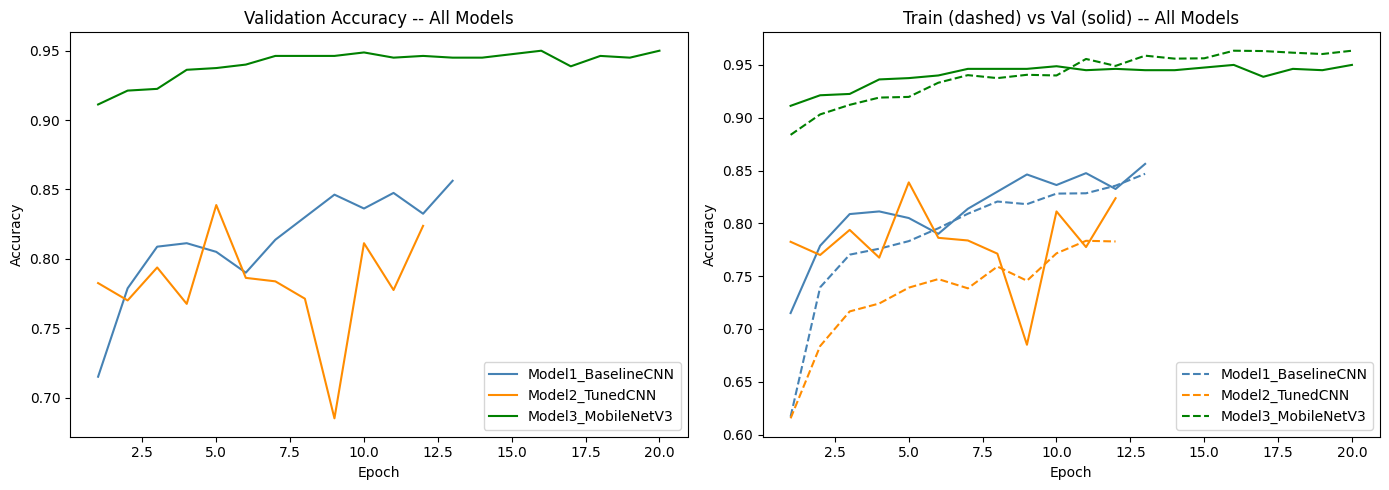

Saved: /content/checkpoints/comparison_accuracy.png


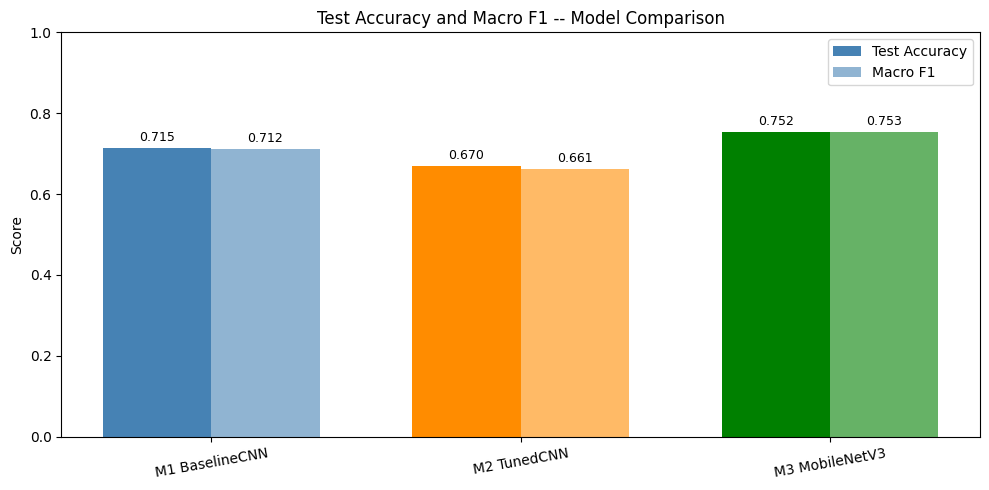

Saved: /content/checkpoints/comparison_bar.png


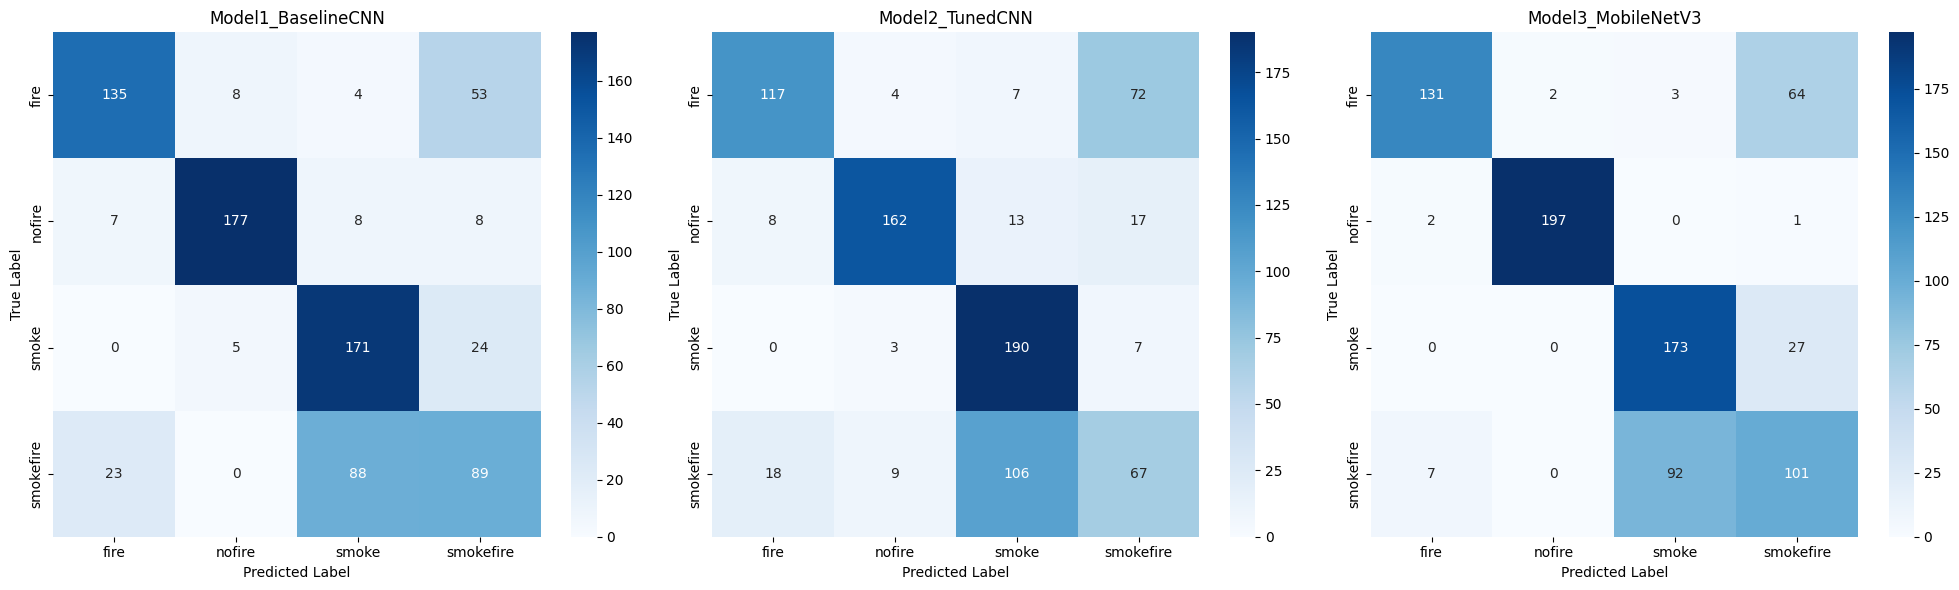

Saved: /content/checkpoints/comparison_confusion_matrices.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Comparison charts downloaded.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

histories = [history1, history2, history3]
colors    = ['steelblue', 'darkorange', 'green']

# 1. Summary table

print("=" * 75)
print(f"{'Model':<28} {'Best Val Acc':>14} {'Test Acc':>10} {'F1 (macro)':>12}")
print("-" * 75)
for h in histories:
    f1 = h['report']['macro avg']['f1-score']
    print(f"{h['name']:<28} {h['best_val_acc']:>14.4f} {h['test_acc']:>10.4f} {f1:>12.4f}")
print("=" * 75)

# Per-class F1 breakdown
print("\nPer-class F1-score comparison:")
print(f"{'Class':<14}", end="")
for h in histories:
    print(f"{h['name'][:18]:>20}", end="")
print()
print("-" * 75)
for cls in CLASS_NAMES:
    print(f"{cls:<14}", end="")
    for h in histories:
        f1 = h['report'][cls]['f1-score']
        print(f"{f1:>20.4f}", end="")
    print()

# 2. Overlay accuracy curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for h, c in zip(histories, colors):
    epochs = range(1, len(h['train_accs']) + 1)
    ax1.plot(epochs, h['val_accs'],   label=h['name'], color=c)
    ax2.plot(epochs, h['train_accs'], label=h['name'], color=c, linestyle='--')
    ax2.plot(epochs, h['val_accs'],   color=c)

ax1.set_title('Validation Accuracy -- All Models')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.set_title('Train (dashed) vs Val (solid) -- All Models')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comparison_accuracy.png', dpi=150)
plt.show()
print(f"Saved: {SAVE_DIR}/comparison_accuracy.png")

# 3. Bar chart -- test accuracy and macro F1

model_names = [h['name'].replace('Model', 'M').replace('_', ' ') for h in histories]
test_accs   = [h['test_acc'] for h in histories]
macro_f1s   = [h['report']['macro avg']['f1-score'] for h in histories]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy', color=colors)
bars2 = ax.bar(x + width/2, macro_f1s, width, label='Macro F1',      color=colors, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Test Accuracy and Macro F1 -- Model Comparison')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comparison_bar.png', dpi=150)
plt.show()
print(f"Saved: {SAVE_DIR}/comparison_bar.png")

# 4. Side-by-side confusion matrices

from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, h, c in zip(axes, histories, colors):
    cm = confusion_matrix(h['labels_true'], h['labels_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(h['name'])
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comparison_confusion_matrices.png', dpi=150)
plt.show()
print(f"Saved: {SAVE_DIR}/comparison_confusion_matrices.png")

# Download comparison charts
from google.colab import files
files.download(f'{SAVE_DIR}/comparison_accuracy.png')
files.download(f'{SAVE_DIR}/comparison_bar.png')
files.download(f'{SAVE_DIR}/comparison_confusion_matrices.png')
print("Comparison charts downloaded.")

## 11. Exporting All 3 Models to ONNX

In [ ]:
import torch
import onnx
import os

ONNX_DIR = '/content/onnx_final'
os.makedirs(ONNX_DIR, exist_ok=True)

def export_legacy(model, model_name, save_dir):
    model.eval()
    model.cpu()
    dummy = torch.randn(1, 3, 224, 224)
    path  = f'{save_dir}/{model_name}.onnx'

    torch.onnx.export(
        model,
        dummy,
        path,
        dynamo              = False,
        export_params       = True,
        opset_version       = 17,
        do_constant_folding = True,
        input_names         = ['input'],
        output_names        = ['output'],
    )

    m = onnx.load(path)
    size_mb      = os.path.getsize(path) / (1024 * 1024)
    weight_count = len(m.graph.initializer)
    print(f'{model_name}: {size_mb:.2f} MB  |  weight tensors: {weight_count}')

    model.to(DEVICE)
    return path

p1 = export_legacy(model1, 'model1_baseline_cnn', ONNX_DIR)
p2 = export_legacy(model2, 'model2_tuned_cnn',    ONNX_DIR)
p3 = export_legacy(model3, 'model3_mobilenetv3',  ONNX_DIR)

# Download ONNX files to local PC (Colab specific)
from google.colab import files
files.download(p1)
files.download(p2)
files.download(p3)

/tmp/ipykernel_2313/2216938313.py:18: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


model1_baseline_cnn: 98.36 MB  |  weight tensors: 10
model2_tuned_cnn: 196.37 MB  |  weight tensors: 10
model3_mobilenetv3: 5.81 MB  |  weight tensors: 108


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install onnxscript --quiet

import torch
import onnx
import os

ONNX_DIR = '/content/onnx_models'
os.makedirs(ONNX_DIR, exist_ok=True)

dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)

def export_to_onnx(model, model_name, dummy_input, save_dir):
    model.eval()
    path = f'{save_dir}/{model_name}.onnx'
    torch.onnx.export(
        model,
        dummy_input,
        path,
        export_params=True,
        opset_version=18, # Changed from 11 to 18 to match ONNX exporter's internal version
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
    )
    # Verify
    onnx_model = onnx.load(path)
    onnx.checker.check_model(onnx_model)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"Exported: {path}  ({size_mb:.1f} MB)")
    return path

path1 = export_to_onnx(model1, 'model1_baseline_cnn',  dummy_input, ONNX_DIR)
path2 = export_to_onnx(model2, 'model2_tuned_cnn',     dummy_input, ONNX_DIR)
path3 = export_to_onnx(model3, 'model3_mobilenetv3',   dummy_input, ONNX_DIR)

print("\nAll models exported to ONNX successfully.")
print("These files will be used by the HTML UI to run inference in the browser.")

# Download all ONNX files
from google.colab import files
files.download(path1)
files.download(path2)
files.download(path3)
print("ONNX model downloads started -- save to your CV_Coursework_Final folder.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 11.2 MB/s eta 0:00:00


/tmp/ipykernel_2313/646191250.py:17: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0517 13:51:24.376000 2313 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0517 13:51:24.377000 2313 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0517 13:51:24.379000 2313 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: '

[torch.onnx] Obtain model graph for `BaselineCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BaselineCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Exported: /content/onnx_models/model1_baseline_cnn.onnx  (0.0 MB)


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ONNX model downloads started -- save to your CV_Coursework_Final folder.


In [ ]:
!pip install gradio --quiet

import gradio as gr
import torch
import torch.nn as nn
import numpy as np
from torchvision import transforms, models
from PIL import Image

# -- Transforms (same as training)
infer_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

CLASSES = ['fire', 'nofire', 'smoke', 'smokefire']

def predict_all(image):
    if image is None:
        return "No image provided", "No image provided", "No image provided"

    img = Image.fromarray(image).convert('RGB')
    tensor = infer_transforms(img).unsqueeze(0).to(DEVICE)

    results = []
    for i, (model, name) in enumerate(
        [(model1, 'Baseline CNN'),
         (model2, 'Tuned CNN'),
         (model3, 'MobileNetV3')], 1):

        model.eval()
        with torch.no_grad():
            logits = model(tensor)
            probs  = torch.softmax(logits, dim=1)[0].cpu().numpy()

        pred_idx  = probs.argmax()
        pred_cls  = CLASSES[pred_idx]
        pred_conf = probs[pred_idx] * 100

        lines = [f"Prediction : {pred_cls.upper()}  ({pred_conf:.1f}%)"]
        lines.append("-" * 34)
        for cls, p in zip(CLASSES, probs):
            bar    = int(p * 20) * "█"
            lines.append(f"{cls:<12} {bar:<20} {p*100:5.1f}%")

        results.append("\n".join(lines))

    return results[0], results[1], results[2]


with gr.Blocks(title="Forest Fire Detection") as demo:
    gr.Markdown("## Forest Fire Detection System")
    gr.Markdown("Upload an image to run all 3 trained models simultaneously.")

    with gr.Row():
        img_input = gr.Image(label="Input Image", type="numpy")

    btn = gr.Button("Run All 3 Models", variant="primary")

    with gr.Row():
        out1 = gr.Textbox(label="Model 1 -- Baseline CNN",  lines=7)
        out2 = gr.Textbox(label="Model 2 -- Tuned CNN",     lines=7)
        out3 = gr.Textbox(label="Model 3 -- MobileNetV3",   lines=7)

    btn.click(fn=predict_all, inputs=img_input, outputs=[out1, out2, out3])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3eb4a7bcb3ccdfc6e4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
